In [4]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for data visualization
%matplotlib inline


In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [7]:
import warnings

warnings.filterwarnings('ignore')


In [9]:
data = 'data.csv'

df = pd.read_csv(data, header=None)

In [10]:
# view dimensions of dataset

df.shape

(570, 33)

In [11]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,NaN
1,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN
2,842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902,NaN
3,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,...,25.53,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758,NaN
4,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173,NaN


In [12]:
col_names = ['Id', 'Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 
             'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']
df.columns = col_names

df.columns

ValueError: Length mismatch: Expected axis has 33 elements, new values have 11 elements

In [13]:
# let's agian preview the dataset

df.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,NaN
1,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN
2,842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902,NaN
3,84300903,M,19.69,21.25,130,1203,0.1096,0.1599,0.1974,0.1279,...,25.53,152.5,1709,0.1444,0.4245,0.4504,0.243,0.3613,0.08758,NaN
4,84348301,M,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,...,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173,NaN


In [14]:
# drop Id column from dataset

df.drop('Id', axis=1, inplace=True)

KeyError: "['Id'] not found in axis"

In [15]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       570 non-null    object 
 1   1       570 non-null    object 
 2   2       570 non-null    object 
 3   3       570 non-null    object 
 4   4       570 non-null    object 
 5   5       570 non-null    object 
 6   6       570 non-null    object 
 7   7       570 non-null    object 
 8   8       570 non-null    object 
 9   9       570 non-null    object 
 10  10      570 non-null    object 
 11  11      570 non-null    object 
 12  12      570 non-null    object 
 13  13      570 non-null    object 
 14  14      570 non-null    object 
 15  15      570 non-null    object 
 16  16      570 non-null    object 
 17  17      570 non-null    object 
 18  18      570 non-null    object 
 19  19      570 non-null    object 
 20  20      570 non-null    object 
 21  21      570 non-null    object 
 22  22

In [16]:
for var in df.columns:
    
    print(df[var].value_counts())

0
92751       1
id          1
842302      1
842517      1
84300903    1
           ..
846381      1
846226      1
84610002    1
845636      1
84501001    1
Name: count, Length: 570, dtype: int64
1
B            357
M            212
diagnosis      1
Name: count, dtype: int64
2
12.34    4
11.06    3
10.26    3
12.77    3
13.05    3
        ..
14.27    1
11.69    1
7.729    1
7.691    1
14.47    1
Name: count, Length: 457, dtype: int64
3
16.84    3
20.52    3
15.7     3
14.93    3
18.22    3
        ..
23.24    1
17.89    1
24.8     1
22.61    1
17.56    1
Name: count, Length: 480, dtype: int64
4
82.61    3
134.7    3
87.76    3
93.97    2
113.4    2
        ..
142      1
131.2    1
108.3    1
140.1    1
102.7    1
Name: count, Length: 523, dtype: int64
5
512.2    3
334.2    2
1076     2
1075     2
716.6    2
        ..
1479     1
1261     1
858.1    1
1265     1
181      1
Name: count, Length: 540, dtype: int64
6
0.1007             5
0.115              4
0.1054             4
0.1075       

In [17]:
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'], errors='coerce')

KeyError: 'Bare_Nuclei'

In [18]:
df.dtypes

0      object
1      object
2      object
3      object
4      object
5      object
6      object
7      object
8      object
9      object
10     object
11     object
12     object
13     object
14     object
15     object
16     object
17     object
18     object
19     object
20     object
21     object
22     object
23     object
24     object
25     object
26     object
27     object
28     object
29     object
30     object
31     object
32    float64
dtype: object

In [19]:
df.isnull().sum()

0       0
1       0
2       0
3       0
4       0
5       0
6       0
7       0
8       0
9       0
10      0
11      0
12      0
13      0
14      0
15      0
16      0
17      0
18      0
19      0
20      0
21      0
22      0
23      0
24      0
25      0
26      0
27      0
28      0
29      0
30      0
31      0
32    570
dtype: int64

In [21]:
df.isna().sum()


0       0
1       0
2       0
3       0
4       0
5       0
6       0
7       0
8       0
9       0
10      0
11      0
12      0
13      0
14      0
15      0
16      0
17      0
18      0
19      0
20      0
21      0
22      0
23      0
24      0
25      0
26      0
27      0
28      0
29      0
30      0
31      0
32    570
dtype: int64

In [27]:
print(df.columns)

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
      dtype='int64')


In [26]:
# check frequency distribution of `Bare_Nuclei` column

df['Bare_Nuclei'].value_counts()
print(df.columns)
df.columns = df.columns.str.strip()


KeyError: 'Bare_Nuclei'

In [25]:
# check unique values in `Bare_Nuclei` column

df['Bare_Nuclei'].unique()

KeyError: 'Bare_Nuclei'

In [ ]:
# check for nan values in `Bare_Nuclei` column

df['Bare_Nuclei'].isna().sum()

In [ ]:
# view frequency distribution of values in `Class` variable

df['Class'].value_counts()

In [ ]:
# view percentage of frequency distribution of values in `Class` variable

df['Class'].value_counts()/np.float(len(df))

In [22]:
# view summary statistics in numerical variables

print(round(df.describe(),2))

        32
count  0.0
mean   NaN
std    NaN
min    NaN
25%    NaN
50%    NaN
75%    NaN
max    NaN


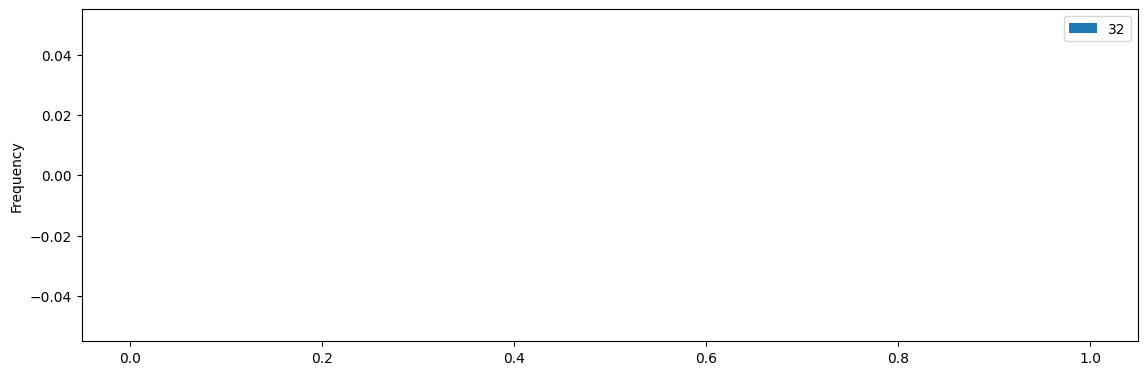

In [23]:
plt.rcParams['figure.figsize']=(30,25)

df.plot(kind='hist', bins=10, subplots=True, layout=(5,2), sharex=False, sharey=False)

plt.show()